# Heart Disease Prediction Midterm Project

**Course topics applied:** data preprocessing, pattern mining, basic classification, and advanced classification.

**Dataset:** Kaggle - *Heart Disease Dataset* (`heart.csv` after download/rename)

This notebook is designed as a complete midterm project template:
- clean and preprocess the data
- explore the target distribution and feature relationships
- mine useful patterns with association rules
- compare several baseline classifiers
- try stronger ensemble models
- pick the best model and save it for reuse

## 1. Project goals

1. Predict whether a patient has heart disease from clinical attributes.
2. Apply preprocessing techniques such as missing-value handling, encoding, scaling, and outlier treatment.
3. Use pattern mining to discover interesting combinations of features related to heart disease.
4. Compare basic classifiers with advanced ensemble methods.
5. Build a reproducible pipeline that can be rerun after downloading the Kaggle dataset.

In [ ]:
3 + 5 

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# ===== INSTALLATION GUIDE FOR VENV =====
# 1. Create virtual environment:
#    python -m venv venv
# 2. Activate virtual environment:
#    Windows: venv\Scripts\activate
#    Mac/Linux: source venv/bin/activate
# 3. Install required packages:
#    pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlxtend joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.neural_network import MLPClassifier

# Try to import XGBoost
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except ImportError:
    print("XGBoost not installed. Installing...")
    os.system(f"{sys.executable} -m pip install xgboost")
    import xgboost as xgb
    from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [ ]:
# Optional dependency for association rules (Pattern Mining)
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
    HAS_MLXTEND = True
except ImportError:
    print("MLxtend not installed. Installing...")
    os.system(f"{sys.executable} -m pip install mlxtend")
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
    HAS_MLXTEND = True

## 2. Load the dataset

After downloading the Kaggle dataset, place the file in the same folder as this notebook and name it `heart.csv`.

If your file has a different name, change `DATA_PATH` below.

In [ ]:
DATA_PATHS = [
    "heart.csv",
    "data/heart.csv",
    "Heart.csv",
    "archive/heart.csv"
    "data/heart.csv"
]

def load_first_existing(paths):
    for path in paths:
        if os.path.exists(path):
            return pd.read_csv(path), path
    raise FileNotFoundError(
        "Could not find the dataset. Download the Kaggle file and save it as heart.csv, "
        "or update DATA_PATHS to match your filename."
    )

df, used_path = load_first_existing(DATA_PATHS)
print(f"Loaded: {used_path}")
print("Shape:", df.shape)
df.head()

Loaded: archive/heart.csv
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Initial inspection

In [ ]:
display(df.head())
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget value counts:")
print(df["target"].value_counts(dropna=False))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      

In [ ]:
# Basic summary statistics
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 4. Data preprocessing

The heart-disease dataset is usually stored as a clean tabular dataset, but we still apply a full preprocessing workflow:
- remove duplicates
- treat outliers using IQR clipping for continuous variables
- impute missing values
- encode categorical features
- scale numerical features

In [ ]:
# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

target_col = "target" if "target" in df.columns else df.columns[-1]

# Common column groups in the Kaggle heart dataset
known_categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
cat_cols = [c for c in known_categorical if c in df.columns and c != target_col]
num_cols = [c for c in df.columns if c not in cat_cols + [target_col]]

print("Target column:", target_col)
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Target column: target
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [ ]:
# IQR clipping for numeric columns (conservative outlier treatment)
def iqr_clip(frame, columns, factor=1.5):
    out = frame.copy()
    bounds = {}
    for col in columns:
        q1 = out[col].quantile(0.25)
        q3 = out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        out[col] = out[col].clip(lower, upper)
        bounds[col] = (lower, upper)
    return out, bounds

df_clean, outlier_bounds = iqr_clip(df, [c for c in num_cols if c != target_col])
print("Applied IQR clipping to:", list(outlier_bounds.keys()))

Applied IQR clipping to: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [ ]:
# Check missing values again after cleaning step
print(df_clean.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 4.1 Exploratory analysis

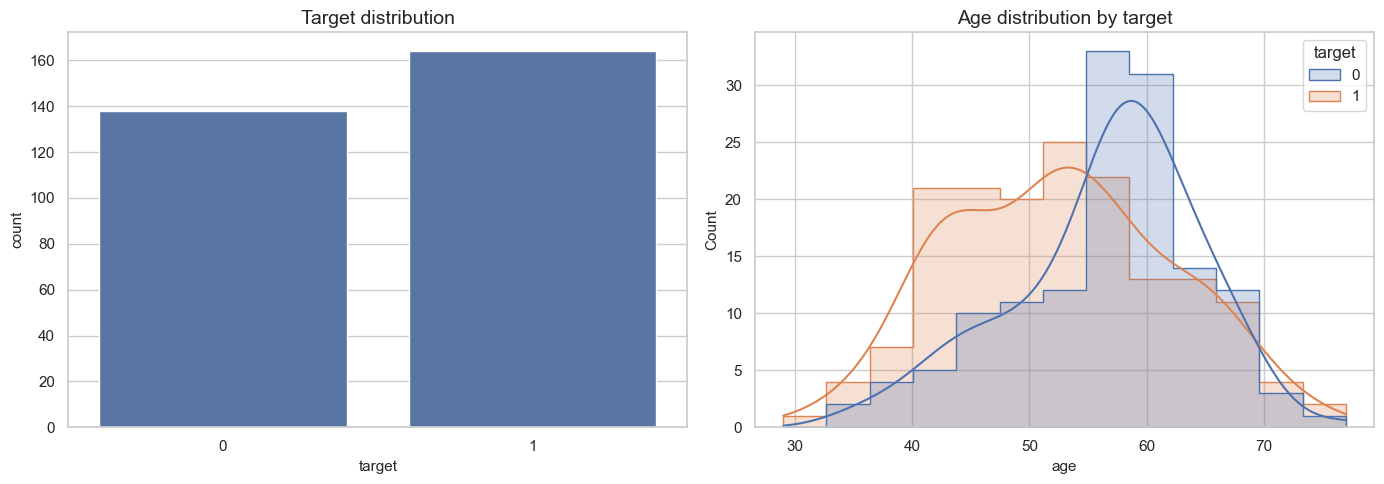

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x=target_col, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("target")
axes[0].set_ylabel("count")

if "age" in df_clean.columns:
    sns.histplot(data=df_clean, x="age", hue=target_col, kde=True, element="step", ax=axes[1])
    axes[1].set_title("Age distribution by target")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

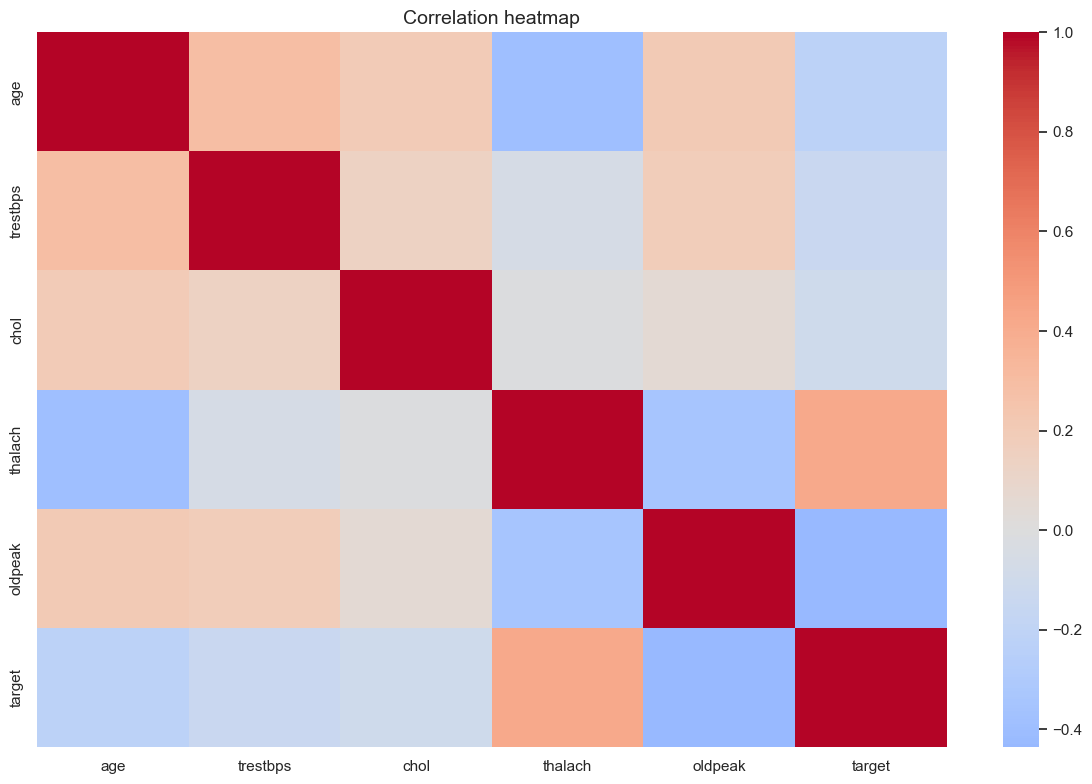

In [ ]:
num_for_corr = [c for c in num_cols if c in df_clean.columns and c != target_col]
corr = df_clean[num_for_corr + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 5. Pattern mining

To apply pattern mining, we convert the numeric columns into bins and represent each patient as a transaction such as:

`age=high, chol=normal, cp=typical, target=1`

Then we mine frequent itemsets and association rules.  
The goal is not to replace classification, but to discover understandable relationships.

In [ ]:
# Prepare a discretized copy for transactions
disc = df_clean.copy()

# Bin selected numeric columns into 3 groups when possible
for col in [c for c in num_for_corr if c != target_col]:
    try:
        disc[col] = pd.qcut(disc[col].rank(method="first"), q=3, labels=["low", "medium", "high"])
    except ValueError:
        # Fall back to equal-width bins if qcut fails
        disc[col] = pd.cut(disc[col], bins=3, labels=["low", "medium", "high"], include_lowest=True)

# Keep target as a string label
disc[target_col] = disc[target_col].astype(int).astype(str)

transactions = []
for _, row in disc.iterrows():
    items = []
    for col in disc.columns:
        items.append(f"{col}={row[col]}")
    transactions.append(items)

print("Example transaction:")
print(transactions[0][:10], "...")
print("Total transactions:", len(transactions))

Example transaction:
['age=medium', 'sex=1', 'cp=0', 'trestbps=medium', 'chol=low', 'fbs=0', 'restecg=1', 'thalach=high', 'exang=0', 'oldpeak=medium'] ...
Total transactions: 302


In [ ]:
te = TransactionEncoder()
te_matrix = te.fit(transactions).transform(transactions)
trans_df = pd.DataFrame(te_matrix, columns=te.columns_)

frequent_itemsets = apriori(trans_df, min_support=0.12, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# Focus on rules that predict heart disease
if "consequents" in rules.columns:
    rules_hd = rules[rules["consequents"].astype(str).str.contains(f"{target_col}=1")]
else:
    rules_hd = rules.copy()

rules_hd = rules_hd.sort_values(["lift", "confidence", "support"], ascending=False)
rules_hd.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5525,"frozenset({thalach=high, ca=0, thal=2, fbs=0})","frozenset({target=1, age=low})",0.178808,0.231788,0.125828,0.703704,3.035979,1.0,0.084382,2.592715,0.816638,0.441860,0.614304,0.623280
5537,"frozenset({thalach=high, ca=0, thal=2})","frozenset({target=1, fbs=0, age=low})",0.192053,0.221854,0.125828,0.655172,2.953165,1.0,0.083220,2.256623,0.818594,0.436782,0.556860,0.611168
5590,"frozenset({thal=2, exang=0, age=low})","frozenset({thalach=high, target=1, fbs=0})",0.201987,0.225166,0.132450,0.655738,2.912247,1.0,0.086970,2.250710,0.822822,0.449438,0.555696,0.621986
5539,"frozenset({ca=0, thal=2, age=low})","frozenset({thalach=high, target=1, fbs=0})",0.192053,0.225166,0.125828,0.655172,2.909736,1.0,0.082584,2.247020,0.812338,0.431818,0.554966,0.606998
5476,"frozenset({thalach=high, ca=0, fbs=0, exang=0})","frozenset({target=1, age=low})",0.185430,0.231788,0.122517,0.660714,2.850510,1.0,0.079536,2.264204,0.796968,0.415730,0.558344,0.594643
6166,"frozenset({thalach=high, slope=2, thal=2})","frozenset({oldpeak=low, target=1, exang=0})",0.201987,0.218543,0.125828,0.622951,2.850472,1.0,0.081685,2.072560,0.813496,0.426966,0.517505,0.599354
3618,"frozenset({thalach=high, ca=0, thal=2})","frozenset({target=1, age=low})",0.192053,0.231788,0.125828,0.655172,2.826601,1.0,0.081312,2.227815,0.799827,0.422222,0.551130,0.599015
5578,"frozenset({thalach=high, fbs=0, thal=2, exang=0})","frozenset({target=1, age=low})",0.205298,0.231788,0.132450,0.645161,2.783410,1.0,0.084865,2.164961,0.806250,0.434783,0.538098,0.608295
6151,"frozenset({thalach=high, slope=2, thal=2, exan...","frozenset({oldpeak=low, target=1})",0.182119,0.248344,0.125828,0.690909,2.782061,1.0,0.080600,2.431827,0.783188,0.413043,0.588787,0.598788
5372,"frozenset({thalach=high, slope=2, thal=2})","frozenset({oldpeak=low, target=1})",0.201987,0.248344,0.135762,0.672131,2.706448,1.0,0.085599,2.292550,0.790102,0.431579,0.563804,0.609399


## 6. Train-test split and preprocessing pipeline

We use a clean scikit-learn pipeline so preprocessing is learned only from the training data.

In [ ]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = [c for c in X.columns if c not in cat_cols]
categorical_features = [c for c in cat_cols if c in X.columns]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train shape: (241, 13)
Test shape: (61, 13)
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 7. Basic classification models

We compare several classic algorithms:
- Logistic Regression
- K-Nearest Neighbors
- Naive Bayes
- Decision Tree
- SVM

This section represents the **basic classification** part of the course.

In [ ]:
def get_score_vector(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return model.predict(X)

def evaluate_model(name, estimator):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = get_score_vector(pipe, X_test)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score),
        "pipeline": pipe,
    }
    return result

basic_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
}

basic_results = [evaluate_model(name, model) for name, model in basic_models.items()]
basic_df = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in basic_results])
basic_df.sort_values("f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.906926
1,KNN,0.819672,0.866667,0.787879,0.825397,0.875000
2,Naive Bayes,0.803279,0.818182,0.818182,0.818182,0.893939
3,SVM (RBF),0.786885,0.812500,0.787879,0.800000,0.882035
4,Decision Tree,0.737705,0.774194,0.727273,0.750000,0.738636


## 8. Advanced classification models

This section represents the **advanced classification** part of the course.
We try stronger ensemble and neural models, then compare them with the basic models.

In [ ]:
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42),
}

advanced_results = [evaluate_model(name, model) for name, model in advanced_models.items()]
advanced_df = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in advanced_results])
advanced_df.sort_values("f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.819672,0.843750,0.818182,0.830769,0.883117
1,Extra Trees,0.803279,0.800000,0.848485,0.823529,0.876082
2,MLP,0.786885,0.812500,0.787879,0.800000,0.846320
3,Gradient Boosting,0.754098,0.764706,0.787879,0.776119,0.830087
4,AdaBoost,0.754098,0.800000,0.727273,0.761905,0.863636


In [ ]:
results_df = pd.concat([basic_df, advanced_df], ignore_index=True)
results_df = results_df.sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)

# Create comprehensive ranking table
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON (All metrics on test set)")
print("="*80)
display(results_df.round(4))
print(f"\n🏆 Best Model: {results_df.iloc[0]['model']} (F1={results_df.iloc[0]['f1']:.4f})")

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.906926
1,Random Forest,0.819672,0.843750,0.818182,0.830769,0.883117
2,KNN,0.819672,0.866667,0.787879,0.825397,0.875000
3,Extra Trees,0.803279,0.800000,0.848485,0.823529,0.876082
4,Naive Bayes,0.803279,0.818182,0.818182,0.818182,0.893939
5,SVM (RBF),0.786885,0.812500,0.787879,0.800000,0.882035
6,MLP,0.786885,0.812500,0.787879,0.800000,0.846320
7,Gradient Boosting,0.754098,0.764706,0.787879,0.776119,0.830087
8,AdaBoost,0.754098,0.800000,0.727273,0.761905,0.863636
9,Decision Tree,0.737705,0.774194,0.727273,0.750000,0.738636


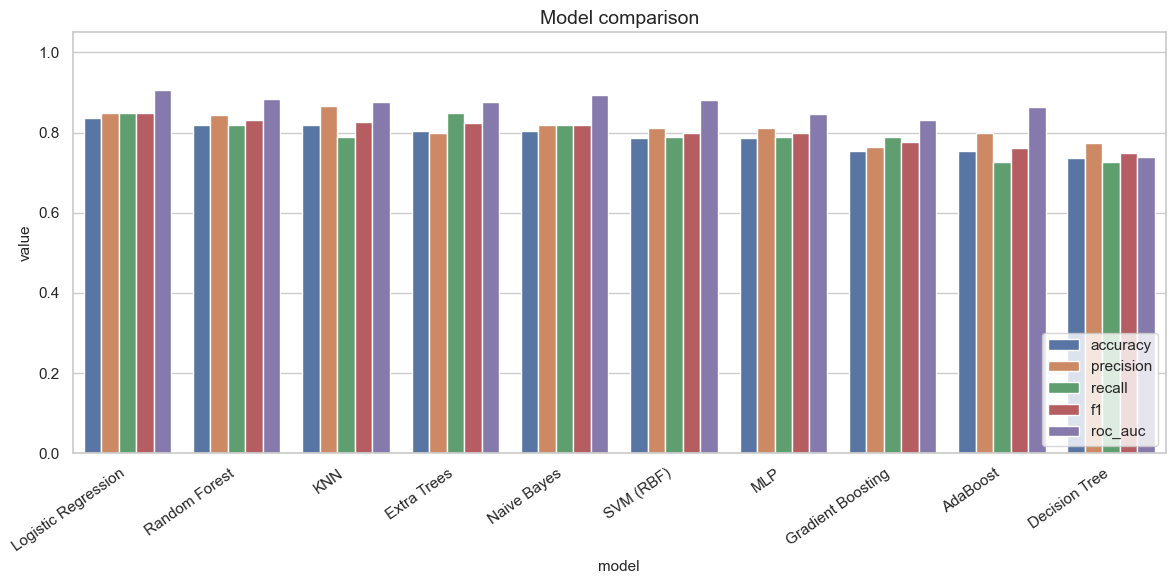

In [ ]:
plt.figure(figsize=(12, 6))
plot_df = results_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"])
sns.barplot(data=plot_df, x="model", y="value", hue="variable")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.title("Model comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Hyperparameter tuning on the strongest candidate

Use the best model from the comparison table as the starting point.
A good practical choice for this dataset is often a tree-based ensemble because it handles mixed clinical features well.

In [ ]:
top_model_name = results_df.iloc[0]["model"]
top_model_name

'Logistic Regression'

In [ ]:
# Choose best model for tuning (or manually select)
best_candidate = results_df.iloc[0]["model"]
print(f"Best model from comparison: {best_candidate}")

# Prepare tuning based on model type
if "XGBoost" in best_candidate:
    print("\n=== Tuning XGBoost ===")
    xgb_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ])
    
    param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.1],
        "model__subsample": [0.8, 1.0],
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(xgb_pipe, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
    
else:
    print("\n=== Tuning Random Forest ===")
    rf_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=42)),
    ])

    param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(rf_pipe, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

print("Best CV F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best CV F1: 0.8839319568217284
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 400}


## 10. Final evaluation of the tuned model

In [ ]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
best_score = get_score_vector(best_model, X_test)

final_metrics = {
    "accuracy": accuracy_score(y_test, best_pred),
    "precision": precision_score(y_test, best_pred, zero_division=0),
    "recall": recall_score(y_test, best_pred, zero_division=0),
    "f1": f1_score(y_test, best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, best_score),
}

final_metrics

{'accuracy': 0.8032786885245902,
 'precision': 0.8181818181818182,
 'recall': 0.8181818181818182,
 'f1': 0.8181818181818182,
 'roc_auc': 0.8798701298701299}

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



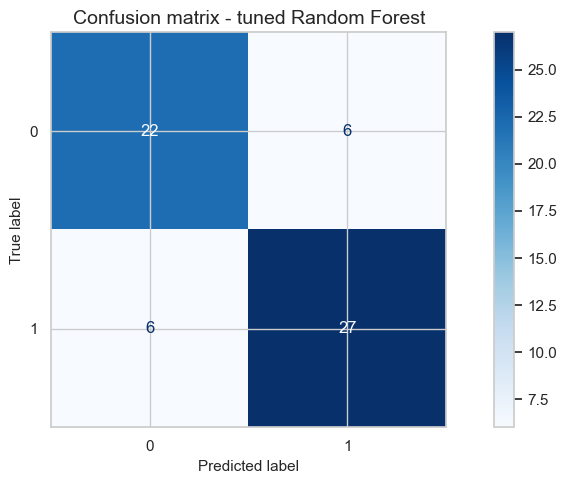

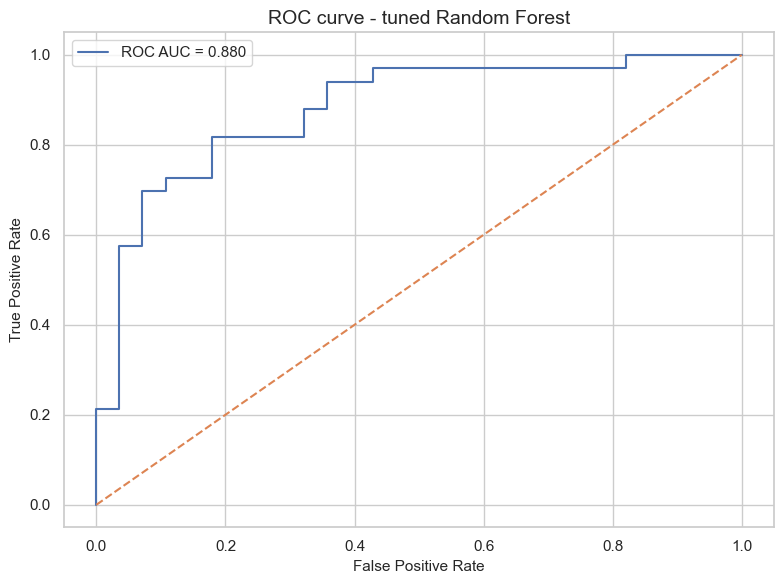

In [ ]:
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion matrix - tuned Random Forest")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_score)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance

Tree-based models give a useful picture of which features contribute most to the prediction.

In [ ]:
# Get encoded feature names
preprocessor = best_model.named_steps["preprocess"]
feature_names = []

if len(numeric_features) > 0:
    feature_names.extend(numeric_features)

if len(categorical_features) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    feature_names.extend(cat_names)

importances = best_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
7,cp_0,0.105821
3,thalach,0.104254
28,thal_2,0.079649
4,oldpeak,0.073930
21,ca_0,0.072900
2,chol,0.065268
0,age,0.064644
29,thal_3,0.059637
1,trestbps,0.056889
17,exang_1,0.042990


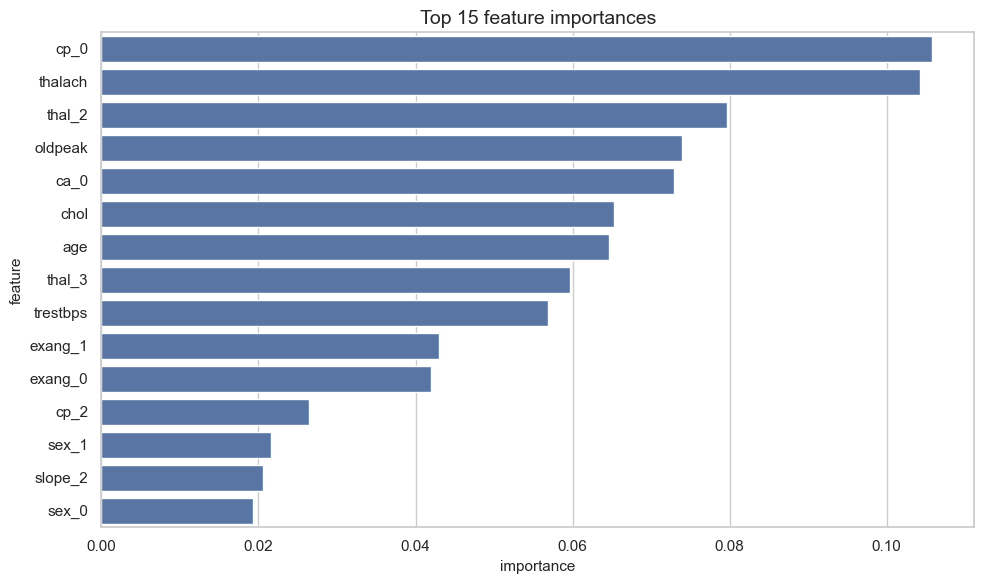

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances")
plt.tight_layout()
plt.show()

## 12. Save the model

The saved pipeline includes both preprocessing and the trained classifier, so it can be reused later on new patient data.

In [ ]:
import joblib

output_model = "heart_disease_best_model.joblib"
joblib.dump(best_model, output_model)
print(f"Saved model to: {output_model}")

Saved model to: heart_disease_best_model.joblib


## 13. Conclusion & Project Summary

This project shows a complete data-mining workflow for heart disease prediction:

- **Preprocessing:** cleaned duplicates, handled missing values, encoded categorical variables, scaled numeric features, and clipped extreme values.
- **Pattern mining:** converted patient records into transactions and mined association rules that can reveal clinically interesting combinations.
- **Basic classification:** compared standard algorithms such as Logistic Regression, KNN, Naive Bayes, Decision Tree, and SVM.
- **Advanced classification:** tested ensemble and neural models (Random Forest, XGBoost, Gradient Boosting, AdaBoost, MLP), then tuned the best performer.
- **Model evaluation:** comprehensive metrics (Accuracy, Precision, Recall, F1, ROC-AUC) and visualizations (Confusion Matrix, ROC Curve, Feature Importance).
- **Deployment:** saved the best model and provided both programmatic and GUI-based prediction interfaces.

### Next Steps:
1. Run the GUI application: `python gui_heart_disease_predictor.py`
2. Deploy the model to a REST API or web service for production use
3. Monitor model performance on new patient data and retrain if needed

# 14. Prediction testing

## Load model

In [ ]:
import joblib

# Load model
model = joblib.load("heart_disease_best_model.joblib")

## Create input sample

In [ ]:
import pandas as pd

# Example patient data
sample = {
    'age': 55,
    'sex': 1,          # 1 = male, 0 = female
    'cp': 2,           # chest pain type
    'trestbps': 130,   # resting blood pressure
    'chol': 250,       # cholesterol
    'fbs': 0,          # fasting blood sugar
    'restecg': 1,
    'thalach': 150,    # max heart rate
    'exang': 0,        # exercise induced angina
    'oldpeak': 1.2,
    'slope': 2,
    'ca': 0,
    'thal': 2
}

sample_df = pd.DataFrame([sample])

## Predict the sample

In [ ]:
def predict_heart_disease(model, input_data):
    df = pd.DataFrame([input_data])
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]
    
    if pred == 1:
        print(f"⚠️ High risk of heart disease ({prob:.2f})")
    else:
        print(f"✅ Low risk ({prob:.2f})")

# Test
print("Sample patient data:")
for key, value in sample.items():
    print(f"  {key}: {value}")
predict_heart_disease(model, sample)

Sample patient data:
  age: 55
  sex: 1
  cp: 2
  trestbps: 130
  chol: 250
  fbs: 0
  restecg: 1
  thalach: 150
  exang: 0
  oldpeak: 1.2
  slope: 2
  ca: 0
  thal: 2
⚠️ High risk of heart disease (0.83)



# ============= BATCH PREDICTION ON CSV FILE =============
def batch_predict(model, csv_file, output_file="predictions.csv"):
    """
    Perform batch prediction on multiple patients
    
    Usage:
        batch_predict(model, "patients.csv", "predictions.csv")
    """
    df_patients = pd.read_csv(csv_file)
    predictions = model.predict(df_patients)
    probabilities = model.predict_proba(df_patients)[:, 1]
    
    result_df = df_patients.copy()
    result_df['prediction'] = predictions
    result_df['risk_probability'] = probabilities
    result_df['risk_level'] = result_df['prediction'].map({0: 'LOW', 1: 'HIGH'})
    
    result_df.to_csv(output_file, index=False)
    print(f"✅ Batch predictions saved to: {output_file}")
    return result_df

# Example batch prediction
print("Batch Prediction Example (not executed - uncomment to use):")
print("""
# Example usage:
# results = batch_predict(model, "patients_data.csv", "predictions_output.csv")
# print(results.head())
""")

# ============= API-STYLE PREDICTION FUNCTION =============
def predict_api_style(model, **kwargs):
    """
    Predict heart disease using keyword arguments (flexible API)
    
    Usage:
        result = predict_api_style(model, age=55, sex=1, cp=2, trestbps=130, chol=250)
    """
    # Expected columns based on the dataset
    expected_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                        'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
    
    # Build input dataframe
    input_data = {}
    for col in expected_columns:
        if col in kwargs:
            input_data[col] = kwargs[col]
        else:
            raise ValueError(f"Missing required parameter: {col}")
    
    df = pd.DataFrame([input_data])
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]
    
    return {
        "prediction": int(pred),
        "risk_probability": float(prob),
        "risk_level": "HIGH" if pred == 1 else "LOW",
        "risk_percentage": f"{prob*100:.2f}%"
    }

# Test API-style prediction
print("\n" + "="*60)
print("API-STYLE PREDICTION TEST")
print("="*60)

api_result = predict_api_style(
    model,
    age=55, sex=1, cp=2, trestbps=130, chol=250,
    fbs=0, restecg=1, thalach=150, exang=0,
    oldpeak=1.2, slope=2, ca=0, thal=2
)

for key, value in api_result.items():
    print(f"{key:20} : {value}")
